# KOD NA TARCZE

✓ Dane wczytane: 24320 wierszy
✓ Zakres siły: 0.0 – 1224.3 N
✓ Zakres accel: 1.1 – 450.7 m/s²

Znaleziono 5 peaków:
  1. t=5.911s → F=1224.3 N
  2. t=1.756s → F=1221.7 N
  3. t=3.877s → F=1191.6 N
  4. t=8.271s → F=1185.2 N
  5. t=10.489s → F=1092.4 N


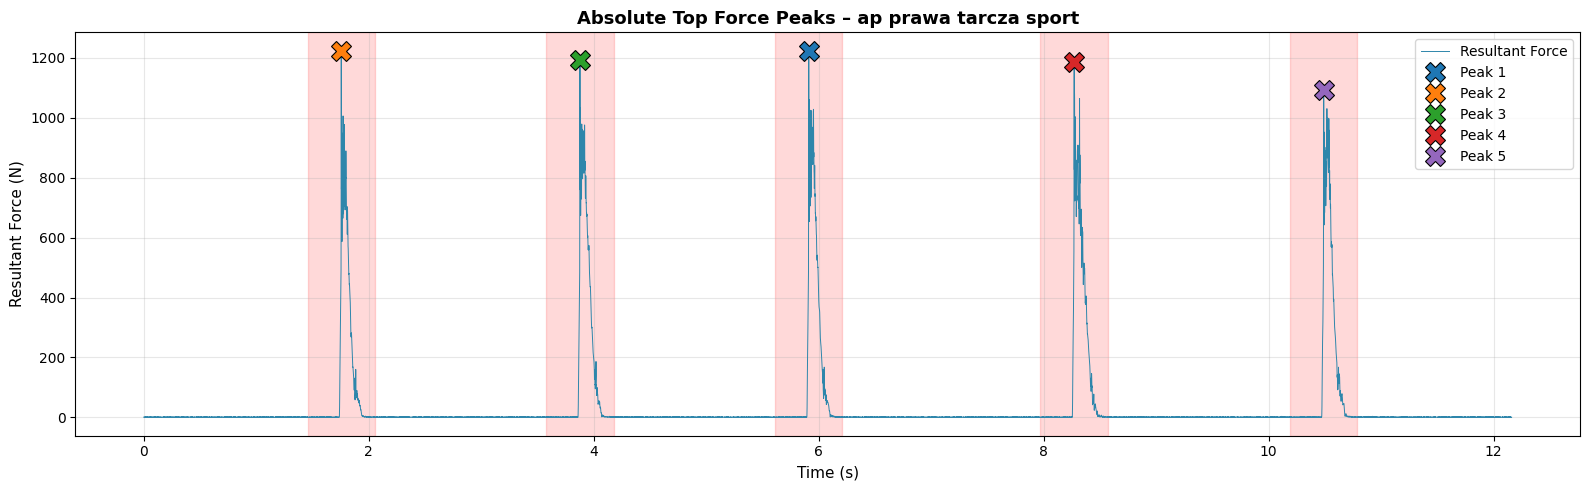


 Event  Time of Max Force (s)  Peak Force (N)  Resultant Accel (m/s²)
     1                 5.9110          1224.3                    57.5
     2                 1.7555          1221.7                    52.5
     3                 3.8770          1191.6                    60.1
     4                 8.2710          1185.2                    51.0
     5                10.4890          1092.4                    52.5

✓ Zapisano: ap prawa tarcza sport (1)_event_1.xlsx (1200 wierszy)
✓ Zapisano: ap prawa tarcza sport (1)_event_2.xlsx (1201 wierszy)
✓ Zapisano: ap prawa tarcza sport (1)_event_3.xlsx (1201 wierszy)


KeyboardInterrupt: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==================== STAŁE ====================
G_TO_MPS2 = 9.80665
MILLI_G_TO_MPS2 = G_TO_MPS2 / 1000
FORCE_THRESHOLD = 400          # ← możesz zmienić (np. 300 lub 500)
WINDOW_SIZE = 0.6
# ===============================================

# === WCZYTANIE I MAPOWANIE KOLUMN ===
data = pd.read_excel('ap prawa tarcza sport (1).xlsx', 
                     sheet_name='ap prawa tarcza sport (1)', 
                     skiprows=3)

# Akcelerometr (używamy sensora 3 — możesz zmienić na 6, 5, 4 lub 9)
data['2x'] = data['Ultium EMG.Accel 3 X,mG'] * MILLI_G_TO_MPS2
data['2y'] = data['Ultium EMG.Accel 3 Y,mG'] * MILLI_G_TO_MPS2
data['2z'] = data['Ultium EMG.Accel 3 Z,mG'] * MILLI_G_TO_MPS2

# Siła z force plate
data['fx'] = data['Force plate Fx,N']
data['fy'] = data['Force plate Fy,N']
data['fz'] = data['Force plate Fz,N']

data['Time'] = data['Time,s']

# === OBLICZENIA RESULTANT (jak w Twoim kodzie) ===
data['resultant_acceleration'] = np.sqrt(data['2x']**2 + data['2y']**2 + data['2z']**2)
data['resultant_force'] = np.sqrt(data['fx']**2 + data['fy']**2 + data['fz']**2)

print(f"✓ Dane wczytane: {len(data)} wierszy")
print(f"✓ Zakres siły: {data['resultant_force'].min():.1f} – {data['resultant_force'].max():.1f} N")
print(f"✓ Zakres accel: {data['resultant_acceleration'].min():.1f} – {data['resultant_acceleration'].max():.1f} m/s²")


def find_absolute_top_peaks(data, min_time_separation=0.5, force_threshold=FORCE_THRESHOLD, num_peaks=5):
    valid_data = data[data['resultant_force'] >= force_threshold]
    sorted_data = valid_data.sort_values(by='resultant_force', ascending=False)
    
    top_peaks = []
    for index, row in sorted_data.iterrows():
        if len(top_peaks) >= num_peaks:
            break
        time_diffs = [abs(row['Time'] - data['Time'].iloc[prev_index]) for prev_index in top_peaks]
        if all(diff >= min_time_separation for diff in time_diffs):
            top_peaks.append(index)
    return top_peaks


def visualize_peaks_and_windows(data, top_peak_indices):
    plt.figure(figsize=(16, 5))
    plt.plot(data['Time'], data['resultant_force'], label='Resultant Force', linewidth=0.7, color='#2E86AB')
    
    for idx, peak_idx in enumerate(top_peak_indices, 1):
        peak_time = data['Time'].iloc[peak_idx]
        plt.plot(peak_time, data['resultant_force'].iloc[peak_idx], 'X', markersize=14, 
                 label=f'Peak {idx}', markeredgecolor='black', markeredgewidth=0.8)
        plt.axvspan(peak_time - WINDOW_SIZE/2, peak_time + WINDOW_SIZE/2, color='red', alpha=0.15)
    
    plt.xlabel('Time (s)', fontsize=11)
    plt.ylabel('Resultant Force (N)', fontsize=11)
    plt.title('Absolute Top Force Peaks – ap prawa tarcza sport', fontsize=13, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def generate_summary_table(data, top_peak_indices):
    summary = []
    for i, peak_idx in enumerate(top_peak_indices):
        row = data.iloc[peak_idx]
        summary.append({
            'Event': i + 1,
            'Time of Max Force (s)': round(row['Time'], 4),
            'Peak Force (N)': round(row['resultant_force'], 1),
            'Resultant Accel (m/s²)': round(row['resultant_acceleration'], 1)
        })
    return pd.DataFrame(summary)


def extract_and_save_events(data, top_peaks, original_file_name='ap prawa tarcza sport (1).xlsx', window_size=WINDOW_SIZE):
    for i, peak_index in enumerate(top_peaks):
        peak_time = data['Time'].iloc[peak_index]
        start_time = peak_time - window_size / 2
        end_time = peak_time + window_size / 2
        event_data = data[(data['Time'] >= start_time) & (data['Time'] <= end_time)].copy()
        
        base_name = original_file_name.rsplit('.', 1)[0]
        event_file_name = f'{base_name}_event_{i + 1}.xlsx'
        event_data.to_excel(event_file_name, index=False)
        print(f'✓ Zapisano: {event_file_name} ({len(event_data)} wierszy)')


def main():
    top_peak_indices = find_absolute_top_peaks(data)
    
    print(f"\nZnaleziono {len(top_peak_indices)} peaków:")
    for i, idx in enumerate(top_peak_indices, 1):
        print(f"  {i}. t={data['Time'].iloc[idx]:.3f}s → F={data['resultant_force'].iloc[idx]:.1f} N")
    
    visualize_peaks_and_windows(data, top_peak_indices)
    
    summary = generate_summary_table(data, top_peak_indices)
    print("\n" + "="*60)
    print(summary.to_string(index=False))
    print("="*60 + "\n")
    
    extract_and_save_events(data, top_peak_indices)


if __name__ == "__main__":
    main()

Plik pocięty na 5 osobnych uderzeń \- teraz możemy uzyska dane o prędkości

✓ Event wczytany: 1200 próbek
✓ Prędkości obliczone
  vel_x range:     -3.03 – 1.92 m/s
  vel_y range:     -0.72 – 6.04 m/s
  vel_z range:     -0.87 – 0.38 m/s
  vel_resultant max: 6.13 m/s


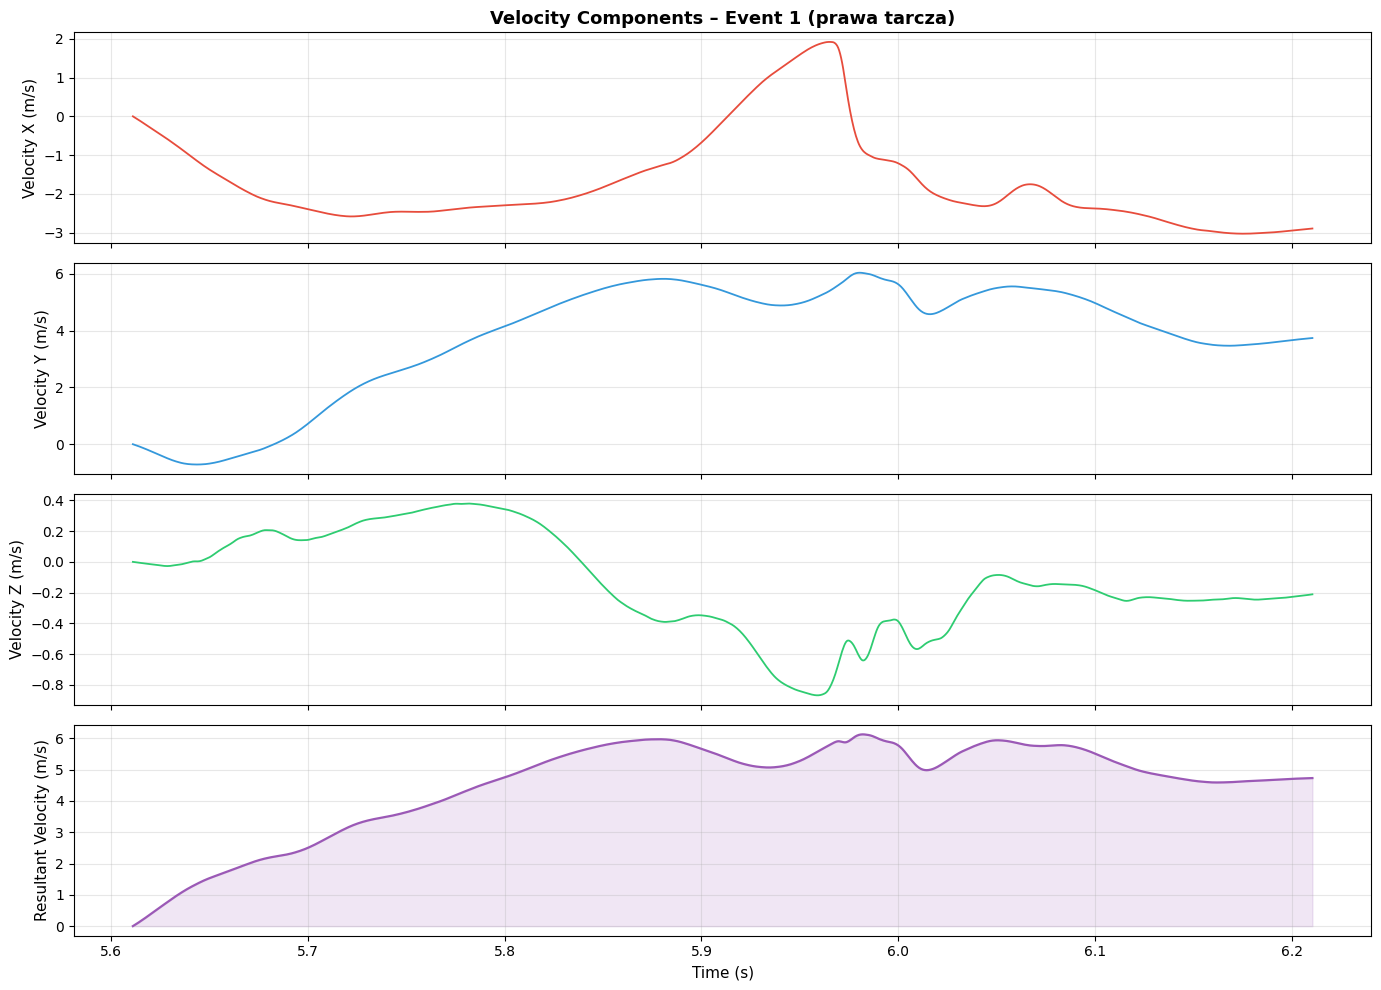


PODSUMOWANIE PRĘDKOŚCI (Event 1 – prawa tarcza)
Max vel_x:        1.92 m/s
Max vel_y:        6.04 m/s
Max vel_z:        0.38 m/s
Max resultant:    6.13 m/s


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================== WCZYTANIE EVENTU ====================
df = pd.read_excel('ap prawa tarcza sport (1)_event_1.xlsx')

print(f"✓ Event wczytany: {len(df)} próbek")

# ==================== POPRAWNA FUNKCJA PRĘDKOŚCI ====================
def compute_velocity(accel, time):
    """
    Oblicza prędkość przez całkowanie przyspieszenia (reguła trapezowa)
    Zwraca tablicę tej samej długości co accel
    """
    dt = np.diff(time)
    vel = np.zeros(len(accel))
    # vel[1:] = cumsum( średnia przyspieszenia * dt )
    vel[1:] = np.cumsum( (accel[:-1] + accel[1:]) / 2 * dt )
    return vel

# ==================== OBLICZENIE PRĘDKOŚCI ====================
df['vel_x'] = compute_velocity(df['2x'].values, df['Time'].values)
df['vel_y'] = compute_velocity(df['2y'].values, df['Time'].values)
df['vel_z'] = compute_velocity(df['2z'].values, df['Time'].values)

# Prędkość resultant
df['vel_resultant'] = np.sqrt(df['vel_x']**2 + df['vel_y']**2 + df['vel_z']**2)

print(f"✓ Prędkości obliczone")
print(f"  vel_x range:     {df['vel_x'].min():.2f} – {df['vel_x'].max():.2f} m/s")
print(f"  vel_y range:     {df['vel_y'].min():.2f} – {df['vel_y'].max():.2f} m/s")
print(f"  vel_z range:     {df['vel_z'].min():.2f} – {df['vel_z'].max():.2f} m/s")
print(f"  vel_resultant max: {df['vel_resultant'].max():.2f} m/s")

# ==================== WYKRESY ====================
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df['Time'], df['vel_x'], color='#E74C3C', linewidth=1.3)
axes[0].set_ylabel('Velocity X (m/s)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Velocity Components – Event 1 (prawa tarcza)', fontsize=13, fontweight='bold')

axes[1].plot(df['Time'], df['vel_y'], color='#3498DB', linewidth=1.3)
axes[1].set_ylabel('Velocity Y (m/s)', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['Time'], df['vel_z'], color='#2ECC71', linewidth=1.3)
axes[2].set_ylabel('Velocity Z (m/s)', fontsize=11)
axes[2].grid(True, alpha=0.3)

axes[3].plot(df['Time'], df['vel_resultant'], color='#9B59B6', linewidth=1.6)
axes[3].fill_between(df['Time'], df['vel_resultant'], alpha=0.15, color='#9B59B6')
axes[3].set_ylabel('Resultant Velocity (m/s)', fontsize=11)
axes[3].set_xlabel('Time (s)', fontsize=11)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== PODSUMOWANIE ====================
print("\n" + "="*55)
print("PODSUMOWANIE PRĘDKOŚCI (Event 1 – prawa tarcza)")
print("="*55)
print(f"Max vel_x:        {df['vel_x'].max():.2f} m/s")
print(f"Max vel_y:        {df['vel_y'].max():.2f} m/s")
print(f"Max vel_z:        {df['vel_z'].max():.2f} m/s")
print(f"Max resultant:    {df['vel_resultant'].max():.2f} m/s")
print("="*55)

teraz dane prędkości i przyspieszenia w momencie kiedy jest max velocity

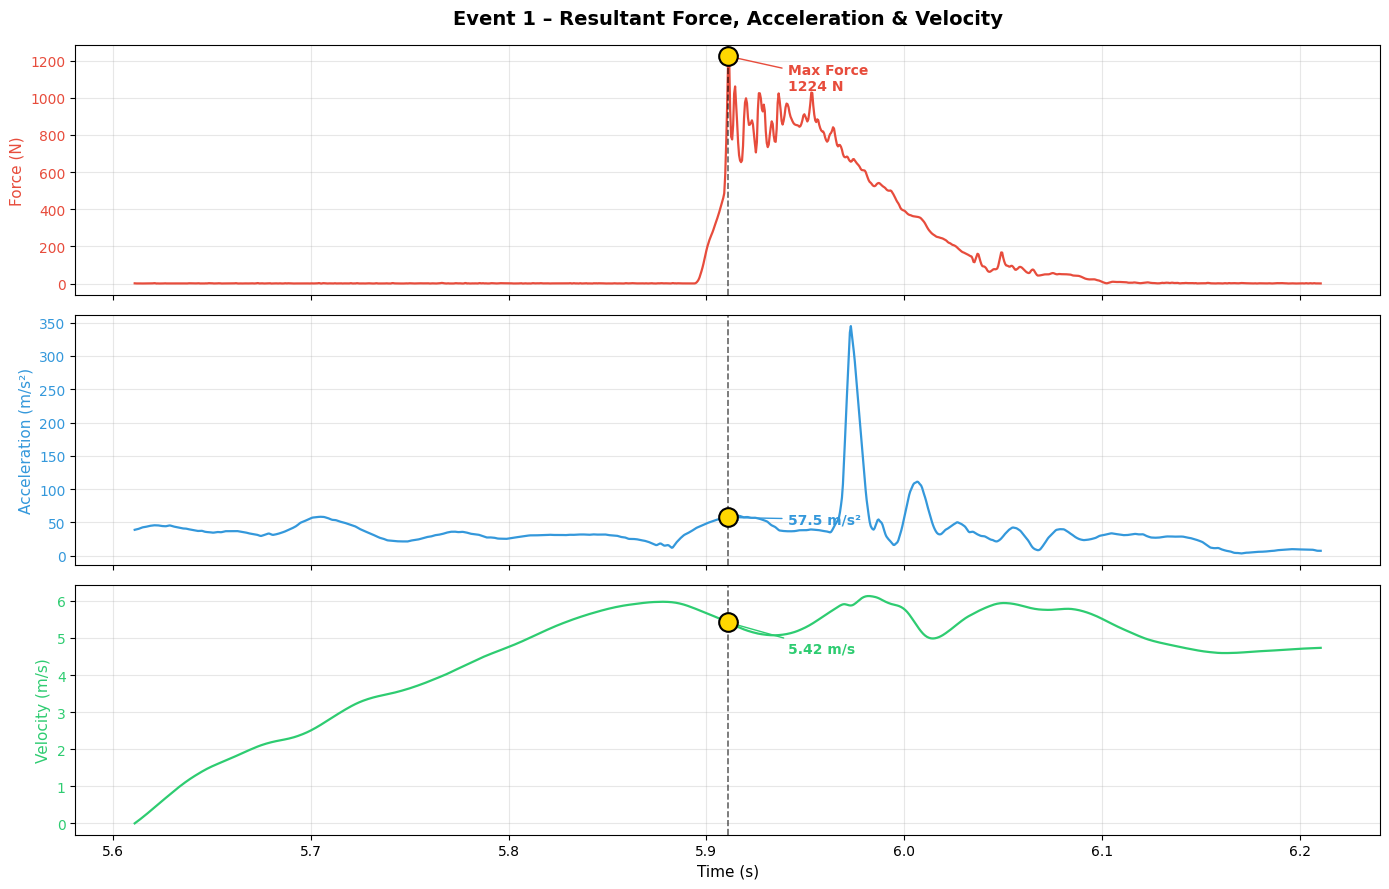


PODSUMOWANIE W MOMENCIE MAKSYMALNEJ SIŁY (Event 1)
Time:                    5.9110 s
Resultant Force:         1224.25 N
Resultant Acceleration:  57.51 m/s²
Resultant Velocity:      5.42 m/s


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================== WCZYTANIE + OBLICZENIA ====================
df = pd.read_excel('ap prawa tarcza sport (1)_event_1.xlsx')

def compute_velocity(accel, time):
    dt = np.diff(time)
    vel = np.zeros(len(accel))
    vel[1:] = np.cumsum( (accel[:-1] + accel[1:]) / 2 * dt )
    return vel

df['vel_x'] = compute_velocity(df['2x'].values, df['Time'].values)
df['vel_y'] = compute_velocity(df['2y'].values, df['Time'].values)
df['vel_z'] = compute_velocity(df['2z'].values, df['Time'].values)
df['vel_resultant'] = np.sqrt(df['vel_x']**2 + df['vel_y']**2 + df['vel_z']**2)

# ==================== MOMENT MAX FORCE ====================
max_idx = df['resultant_force'].idxmax()
max_time = df.loc[max_idx, 'Time']
max_force = df.loc[max_idx, 'resultant_force']
max_acc = df.loc[max_idx, 'resultant_acceleration']
max_vel = df.loc[max_idx, 'vel_resultant']

# ==================== WYKRES 3w1 ====================
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 1. Resultant Force
axes[0].plot(df['Time'], df['resultant_force'], color='#E74C3C', linewidth=1.6, label='Resultant Force')
axes[0].axvline(max_time, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[0].scatter(max_time, max_force, color='gold', s=180, zorder=5, edgecolors='black', linewidth=1.5)
axes[0].annotate(f'Max Force\n{max_force:.0f} N', 
                 xy=(max_time, max_force), xytext=(max_time+0.03, max_force*0.85),
                 fontsize=10, fontweight='bold', color='#E74C3C',
                 arrowprops=dict(arrowstyle='->', color='#E74C3C'))
axes[0].set_ylabel('Force (N)', fontsize=11, color='#E74C3C')
axes[0].tick_params(axis='y', labelcolor='#E74C3C')
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Event 1 – Resultant Force, Acceleration & Velocity', fontsize=14, fontweight='bold', pad=15)

# 2. Resultant Acceleration
axes[1].plot(df['Time'], df['resultant_acceleration'], color='#3498DB', linewidth=1.6, label='Resultant Acceleration')
axes[1].axvline(max_time, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[1].scatter(max_time, max_acc, color='gold', s=180, zorder=5, edgecolors='black', linewidth=1.5)
axes[1].annotate(f'{max_acc:.1f} m/s²', 
                 xy=(max_time, max_acc), xytext=(max_time+0.03, max_acc*0.85),
                 fontsize=10, fontweight='bold', color='#3498DB',
                 arrowprops=dict(arrowstyle='->', color='#3498DB'))
axes[1].set_ylabel('Acceleration (m/s²)', fontsize=11, color='#3498DB')
axes[1].tick_params(axis='y', labelcolor='#3498DB')
axes[1].grid(True, alpha=0.3)

# 3. Resultant Velocity
axes[2].plot(df['Time'], df['vel_resultant'], color='#2ECC71', linewidth=1.6, label='Resultant Velocity')
axes[2].axvline(max_time, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[2].scatter(max_time, max_vel, color='gold', s=180, zorder=5, edgecolors='black', linewidth=1.5)
axes[2].annotate(f'{max_vel:.2f} m/s', 
                 xy=(max_time, max_vel), xytext=(max_time+0.03, max_vel*0.85),
                 fontsize=10, fontweight='bold', color='#2ECC71',
                 arrowprops=dict(arrowstyle='->', color='#2ECC71'))
axes[2].set_ylabel('Velocity (m/s)', fontsize=11, color='#2ECC71')
axes[2].tick_params(axis='y', labelcolor='#2ECC71')
axes[2].set_xlabel('Time (s)', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== TABELA PODSUMOWUJĄCA ====================
print("\n" + "="*60)
print("PODSUMOWANIE W MOMENCIE MAKSYMALNEJ SIŁY (Event 1)")
print("="*60)
print(f"Time:                    {max_time:.4f} s")
print(f"Resultant Force:         {max_force:.2f} N")
print(f"Resultant Acceleration:  {max_acc:.2f} m/s²")
print(f"Resultant Velocity:      {max_vel:.2f} m/s")
print("="*60)

temu dla tarczy nie szukamy wszystkich maksów bo przyspieszenie i prędkos to maxy odbicia od tarczy

# TERAZ KOD NA POWIETRZE

tu bazujemy w cięciu na poszczególne ciosy na przyspieszeniu a nie na wyniku tarczy

✓ Event 1: 10.949–11.149 s (401 próbek)
✓ Event 2: 7.901–8.101 s (400 próbek)
✓ Event 3: 13.736–13.936 s (400 próbek)
✓ Event 4: 9.457–9.656 s (401 próbek)
✓ Event 5: 1.492–1.693 s (401 próbek)


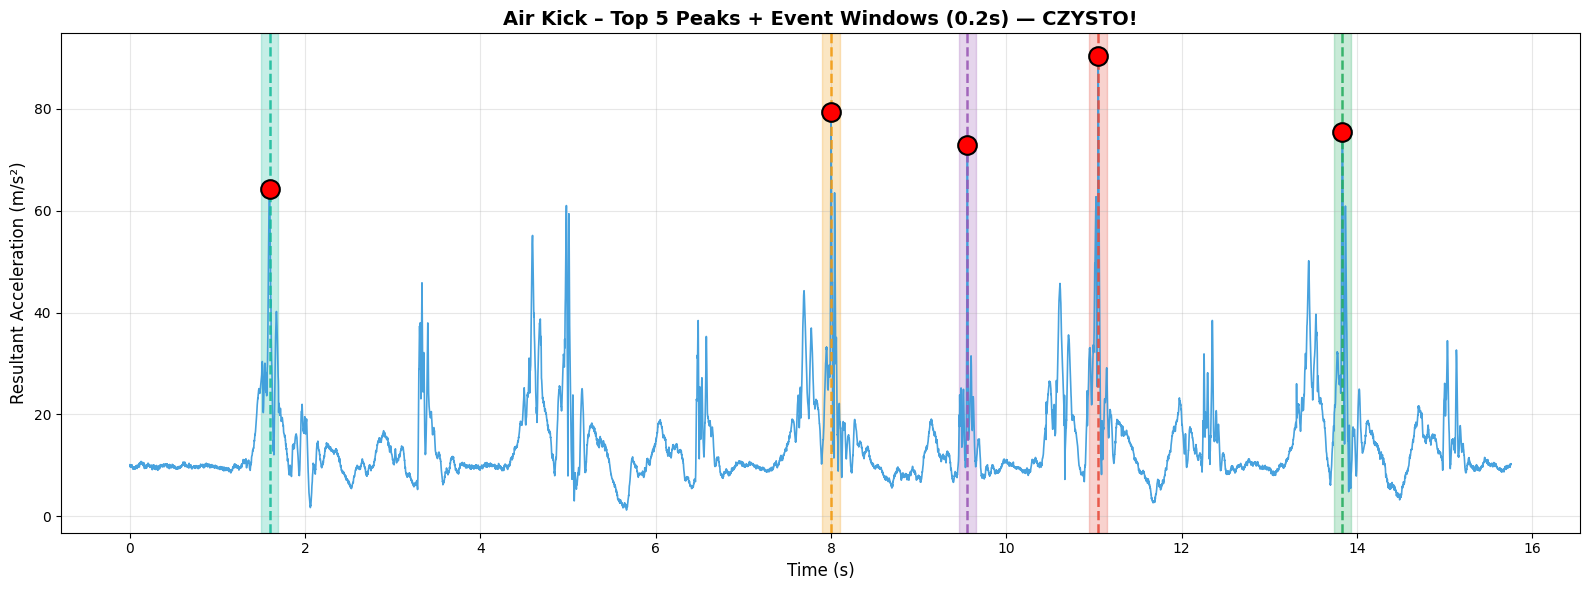

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

df = pd.read_excel('ap lewa air sport.xlsx', sheet_name='ap lewa air sport', skiprows=3)

G_TO_MPS2 = 9.80665
MILLI_G_TO_MPS2 = G_TO_MPS2 / 1000

df['2x'] = df['Ultium EMG.Accel 3 X,mG'] * MILLI_G_TO_MPS2
df['2y'] = df['Ultium EMG.Accel 3 Y,mG'] * MILLI_G_TO_MPS2
df['2z'] = df['Ultium EMG.Accel 3 Z,mG'] * MILLI_G_TO_MPS2
df['Time'] = df['Time,s']
df['resultant_acceleration'] = np.sqrt(df['2x']**2 + df['2y']**2 + df['2z']**2)

peaks, _ = find_peaks(df['resultant_acceleration'], height=25, distance=2000)
top_peaks = sorted(peaks, key=lambda i: df['resultant_acceleration'].iloc[i], reverse=True)[:5]

WINDOW_SIZE = 0.2  # ← ZMIENIONE na 0.2s (200 ms)
base_name = 'ap lewa air sport'

event_files = []
event_ranges = []
for i, peak_idx in enumerate(top_peaks, 1):
    peak_time = df['Time'].iloc[peak_idx]
    start_time = peak_time - WINDOW_SIZE / 2
    end_time = peak_time + WINDOW_SIZE / 2
    
    event_data = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)].copy()
    filename = f'{base_name}_event_{i}.xlsx'
    event_data.to_excel(filename, index=False)
    event_files.append(filename)
    event_ranges.append((start_time, end_time, peak_time))
    print(f"✓ Event {i}: {start_time:.3f}–{end_time:.3f} s ({len(event_data)} próbek)")

# WYKRES
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Time'], df['resultant_acceleration'], color='#3498DB', linewidth=1.2, alpha=0.9)

colors = ['#E74C3C', '#F39C12', '#27AE60', '#9B59B6', '#1ABC9C']
for i, (start, end, peak_time) in enumerate(event_ranges):
    ax.axvspan(start, end, alpha=0.25, color=colors[i])
    ax.axvline(peak_time, color=colors[i], linestyle='--', linewidth=1.8, alpha=0.9)

for i, idx in enumerate(top_peaks, 1):
    ax.scatter(df['Time'].iloc[idx], df['resultant_acceleration'].iloc[idx], 
               color='red', s=180, zorder=5, edgecolors='black', linewidth=1.5)

ax.set_title('Air Kick – Top 5 Peaks + Event Windows (0.2s) — CZYSTO!', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Resultant Acceleration (m/s²)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Event 1 (1.5s window) – Max resultant velocity: 1.34 m/s
  vel_x max: 0.95 m/s
  vel_y max: 1.31 m/s
  vel_z max: 0.17 m/s


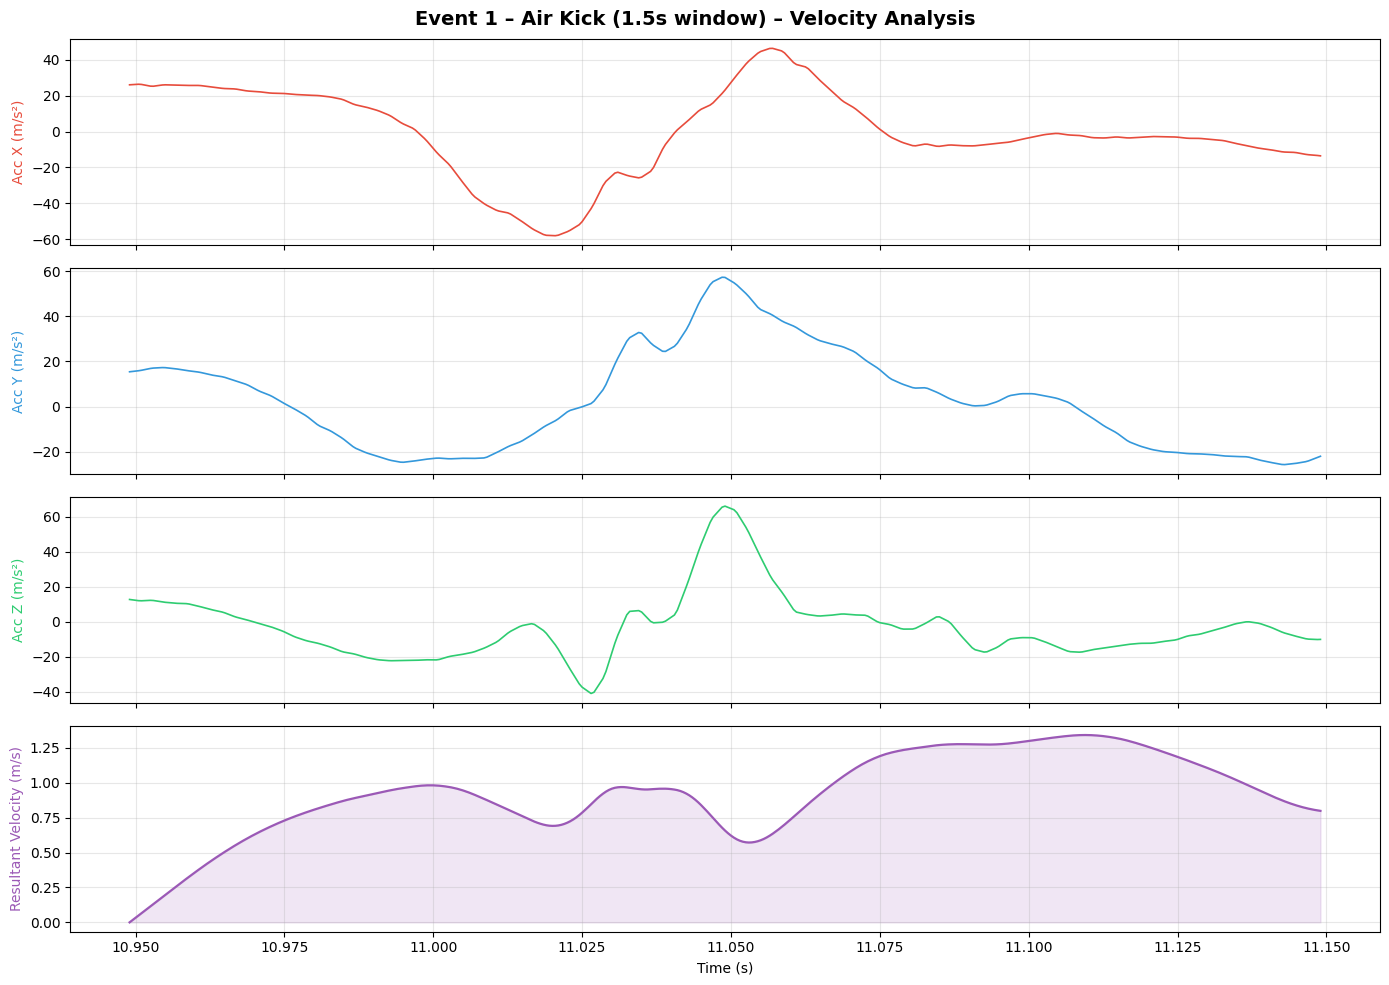

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('/work/ap lewa air sport_event_1.xlsx')

def compute_velocity(accel, time):
    dt = np.diff(time)
    vel = np.zeros(len(accel))
    vel[1:] = np.cumsum( (accel[:-1] + accel[1:]) / 2 * dt )
    return vel

df['vel_x'] = compute_velocity(df['2x'].values, df['Time'].values)
df['vel_y'] = compute_velocity(df['2y'].values, df['Time'].values)
df['vel_z'] = compute_velocity(df['2z'].values, df['Time'].values)
df['vel_resultant'] = np.sqrt(df['vel_x']**2 + df['vel_y']**2 + df['vel_z']**2)

print(f"Event 1 (1.5s window) – Max resultant velocity: {df['vel_resultant'].max():.2f} m/s")
print(f"  vel_x max: {df['vel_x'].max():.2f} m/s")
print(f"  vel_y max: {df['vel_y'].max():.2f} m/s")
print(f"  vel_z max: {df['vel_z'].max():.2f} m/s")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df['Time'], df['2x'], color='#E74C3C', linewidth=1.2)
axes[0].set_ylabel('Acc X (m/s²)', color='#E74C3C')
axes[1].plot(df['Time'], df['2y'], color='#3498DB', linewidth=1.2)
axes[1].set_ylabel('Acc Y (m/s²)', color='#3498DB')
axes[2].plot(df['Time'], df['2z'], color='#2ECC71', linewidth=1.2)
axes[2].set_ylabel('Acc Z (m/s²)', color='#2ECC71')
axes[3].plot(df['Time'], df['vel_resultant'], color='#9B59B6', linewidth=1.6)
axes[3].fill_between(df['Time'], df['vel_resultant'], alpha=0.15, color='#9B59B6')
axes[3].set_ylabel('Resultant Velocity (m/s)', color='#9B59B6')
axes[3].set_xlabel('Time (s)')
for ax in axes: ax.grid(True, alpha=0.3)
plt.suptitle('Event 1 – Air Kick (1.5s window) – Velocity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=df041f88-6920-47c1-80f6-2b62e7875599' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>